In [1]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import cutouts_to_patches.cutouts_to_patches as cutouts_to_patches

In [2]:
import visualization.visualization as vis

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
from nemi import NEMI, SingleNemi

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch
import numpy as np

import colorsys
from einops import rearrange
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

import itertools

In [5]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="1_00",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [ ]:
# cutouts_dataloader = cutouts_dataset.get_cutout_loader(source=source, subset=True, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=1, batch_size=64)
data_channels = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl']

cutouts_dataloader = cutouts_dataset.get_cutout_loader(data_channels=data_channels, source=source, subset=False, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=4, batch_size=64)

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38691 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:36779' processes=4 threads=32, memory=128.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/38691/status


In [ ]:
len(cutouts_dataloader) * 64 

In [ ]:
import math 

patch_size = 8
patched_loader = cutouts_to_patches.PatchedDataLoader(cutouts_dataloader, patch_size=patch_size)
print(len(patched_loader))

patches = torch.cat(
    [patches.reshape(patches.shape[0] * patches.shape[1], -1) for patches in patched_loader], dim=0
).numpy()

print(patches.shape)
print(math.log(patches.shape[0])+15)

In [ ]:
EMBEDDING_DIMENSIONS = 3

In [ ]:
# # Run NEMI on the patches (GPU: cuML UMAP + clustering)
# nemi = NEMI(params={
#     "device": "gpu",
#     "embedding_dict":  {"n_components": EMBEDDING_DIMENSIONS, "n_neighbors": 150, "min_dist": 0.0},
#     "clustering_dict": {"method": "hdbscan", "min_cluster_size": 1000, "min_samples": 500},
# })

# # nemi = NEMI(params={
# #     "device": "gpu",
# #     "embedding_dict":  {"n_components": 2, "n_neighbors": 150, "min_dist": 0.0},
# #     "clustering_dict": {"method": "agglomerative", "n_clusters": 500, "linkage": "single", "n_neighbors": 30},
# # })


# # single member to start; bump n (with assess_overlap=True) for the ensemble
# nemi.run(patches, n=5, output="nemi_out.npz", assess_overlap=True)

# labels    = nemi.clusters      # (N,) cluster label per patch
# embedding = nemi.embedding     # (N, 3) UMAP embedding
# print("labels", labels.shape, "| embedding", embedding.shape)

In [ ]:
d = np.load("nemi_out.npz")
print(d.files) 

member_clusters = d["member_clusters"]  # (n, N)  per-member labels  <- entropy input
embeddings      = d["embeddings"]       # (n, N, d) per-member UMAP embeddings
clusters        = d["clusters"]         # (N,)   consensus labels (assess_overlap ran)
embedding       = d["embedding"]        # (N, d) consensus/base embedding
entropy         = d["entropy"]
unassigned      = d["unassigned_frac"]

print(embeddings.shape)
print(member_clusters.shape)
print(clusters.shape)
print(embedding.shape)
print(entropy.shape)
print(unassigned.shape)

In [13]:
# def distinct_cmap(n):
#     """Qualitative colormap with n visually distinct colors (tab20-style, any n)."""
#     colors = []
#     for i in range(n):
#         h = (i * 0.61803398875) % 1.0        # golden-ratio hue spacing
#         s = 0.55 + 0.35 * (i % 2)            # two saturation tiers
#         v = 0.75 + 0.20 * ((i // 2) % 2)     # two value tiers
#         colors.append(colorsys.hsv_to_rgb(h, s, v))
#     return ListedColormap(colors)

# disc_cmap = distinct_cmap(len(clusters))

In [ ]:
# vis.vis_dim_redux(embeddings[1], labels=entropy, dims=2, alpha=0.5, categorical=False, cmap="viridis")

vis.vis_dim_redux_list(d["embeddings"], labels=entropy, dims=EMBEDDING_DIMENSIONS,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))], categorical=False, cmap="viridis")

In [ ]:
vis.vis_dim_redux_list(d["embeddings"], labels=unassigned, dims=EMBEDDING_DIMENSIONS,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))], categorical=False, cmap="viridis")

In [ ]:
#labeled by consensus cluster
vis.vis_dim_redux_list(d["embeddings"], labels=clusters, dims=EMBEDDING_DIMENSIONS, titles=[f"member {i}" for i in range(len(d["embeddings"]))], alpha=0.5)

In [ ]:
# colored by embedding's clustering
vis.vis_dim_redux_list(d["embeddings"], labels=d["member_clusters"], dims=EMBEDDING_DIMENSIONS,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))])

In [ ]:
np.unique(clusters)

In [ ]:
vis.plot_global_cluster_maps(cutouts_dataloader, patched_loader, clusters, alpha=0.5, point_size=8, extent=None,
                             coastlines=True, panel_size=8, drop_noise=False,
                             save_dir=None)

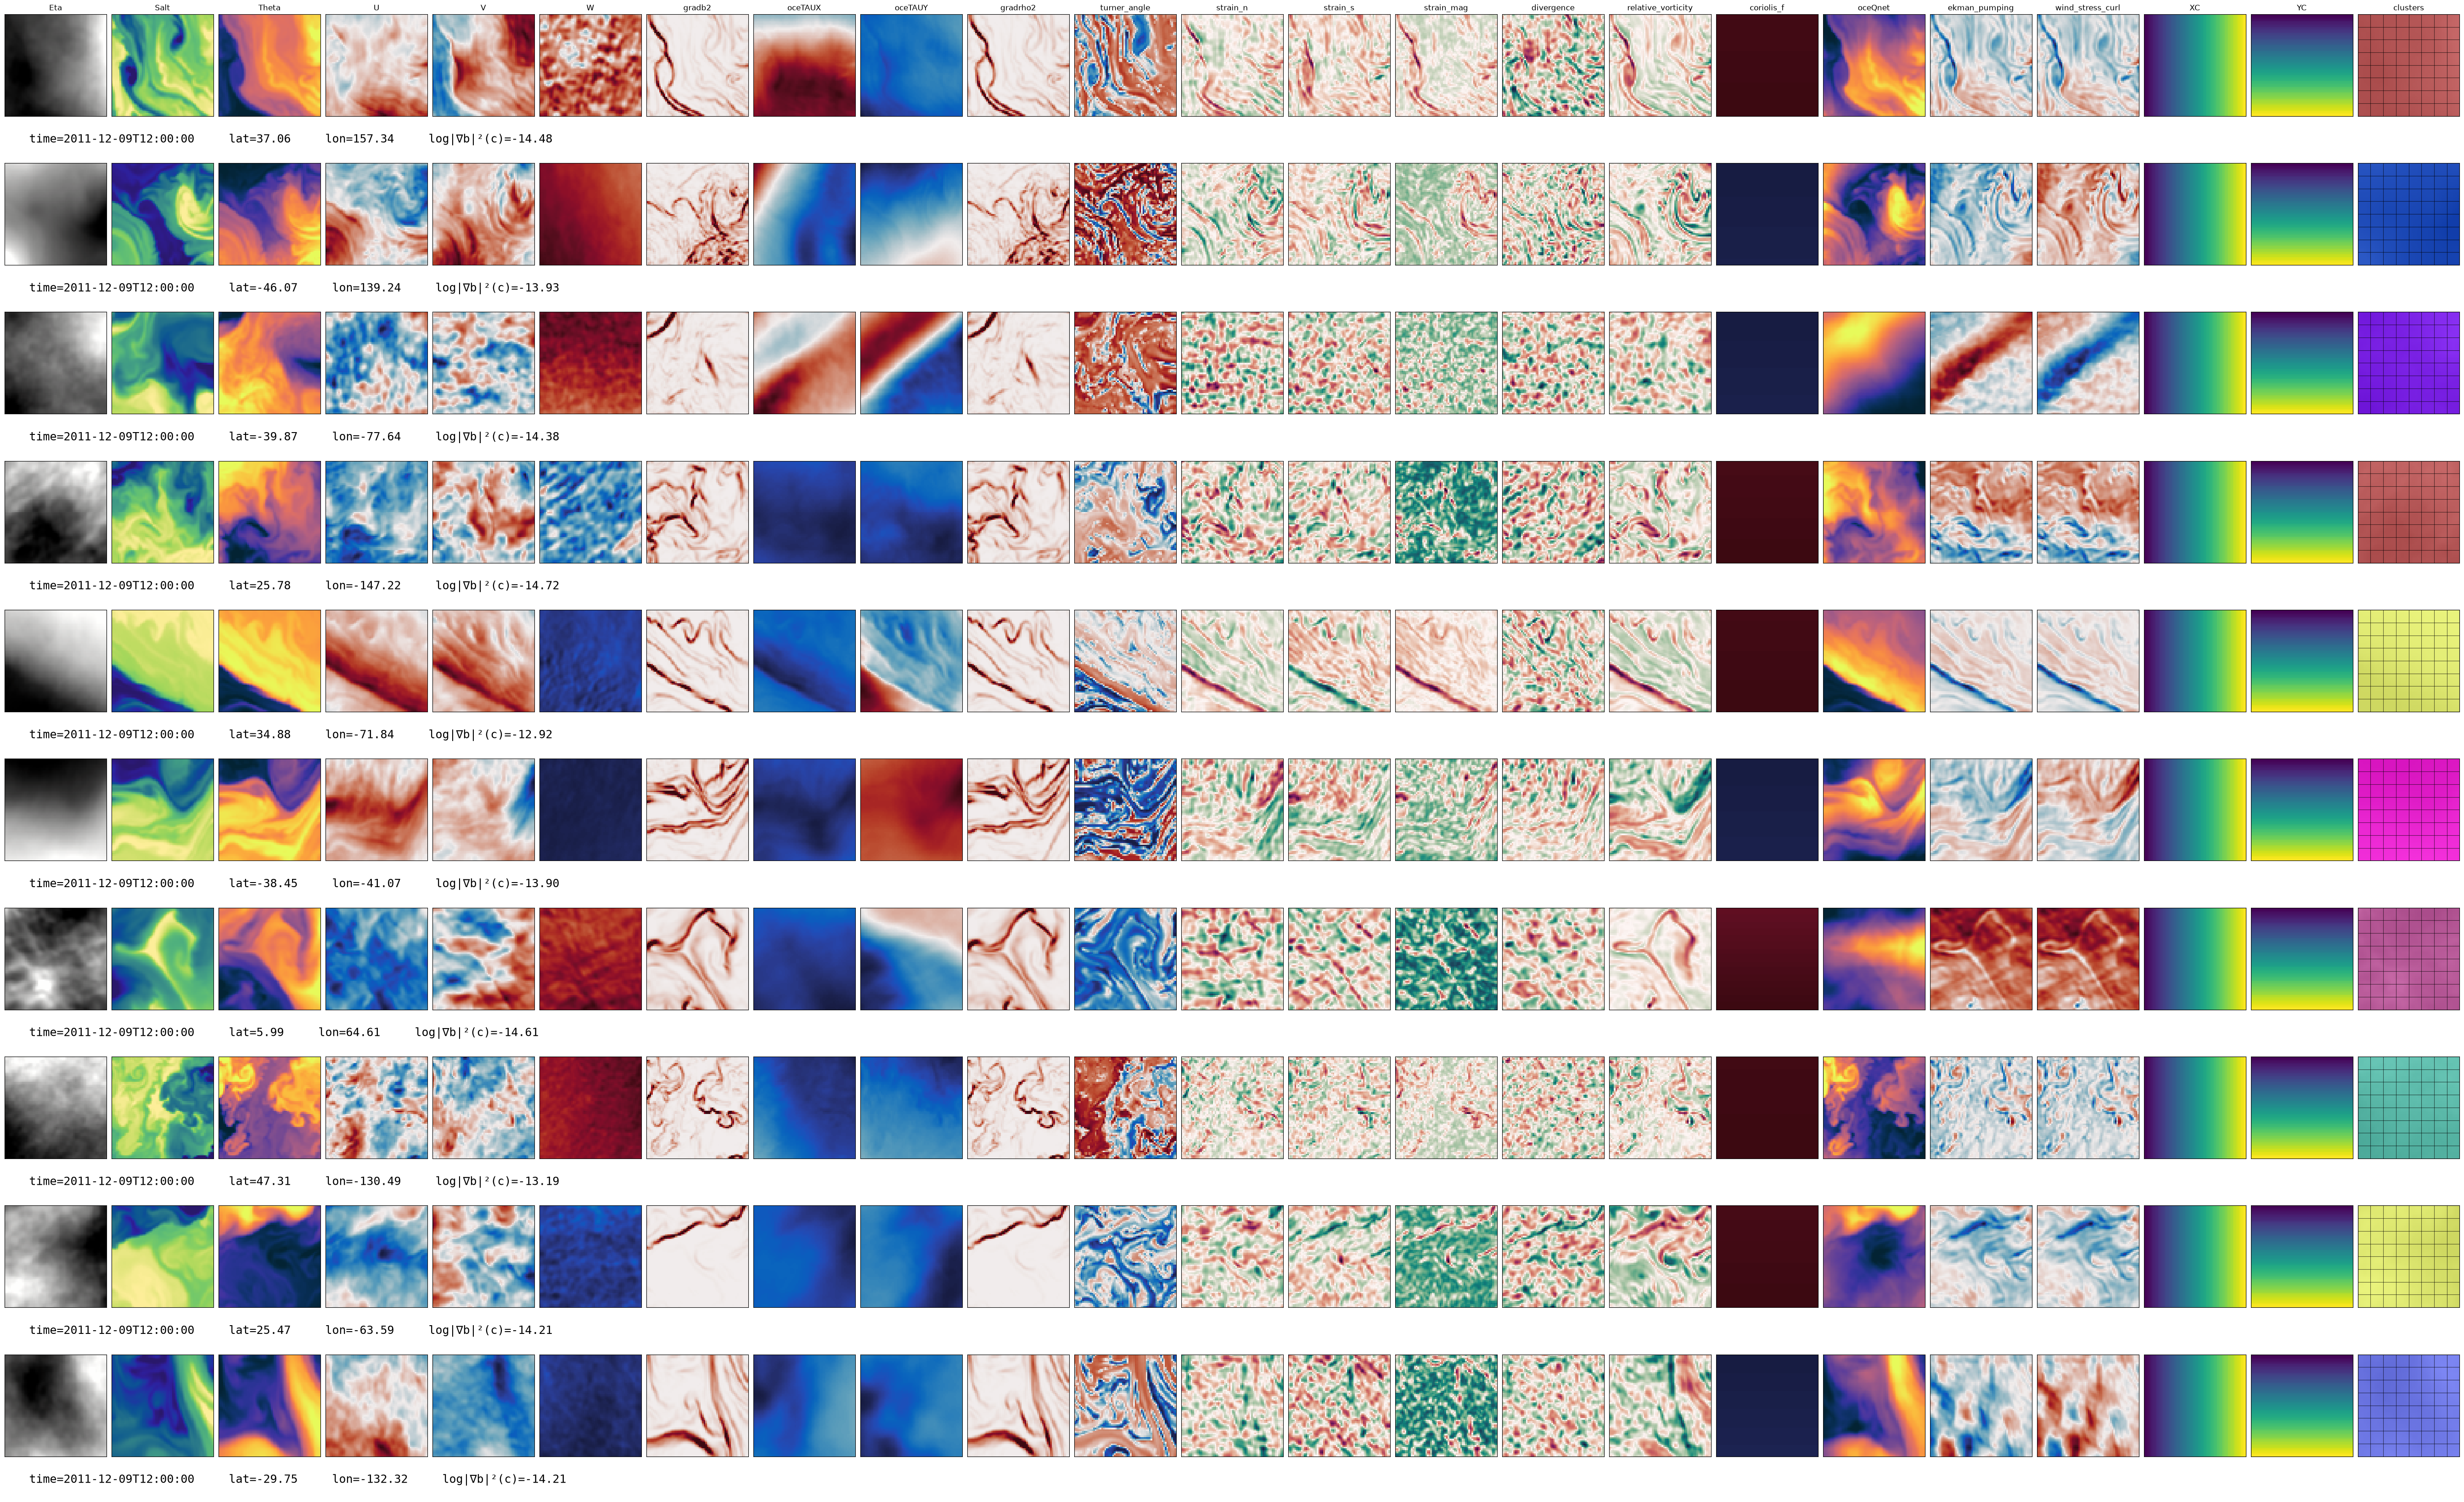

In [19]:
vis.make_image_from_patches(cutouts_dataloader, patched_loader, clusters,
                            batch_index=0, batch_size=64, patch_size=8,
                            number_rows=10)

torch.Size([64, 64, 22, 8, 8])
torch.Size([64, 22, 64, 64])


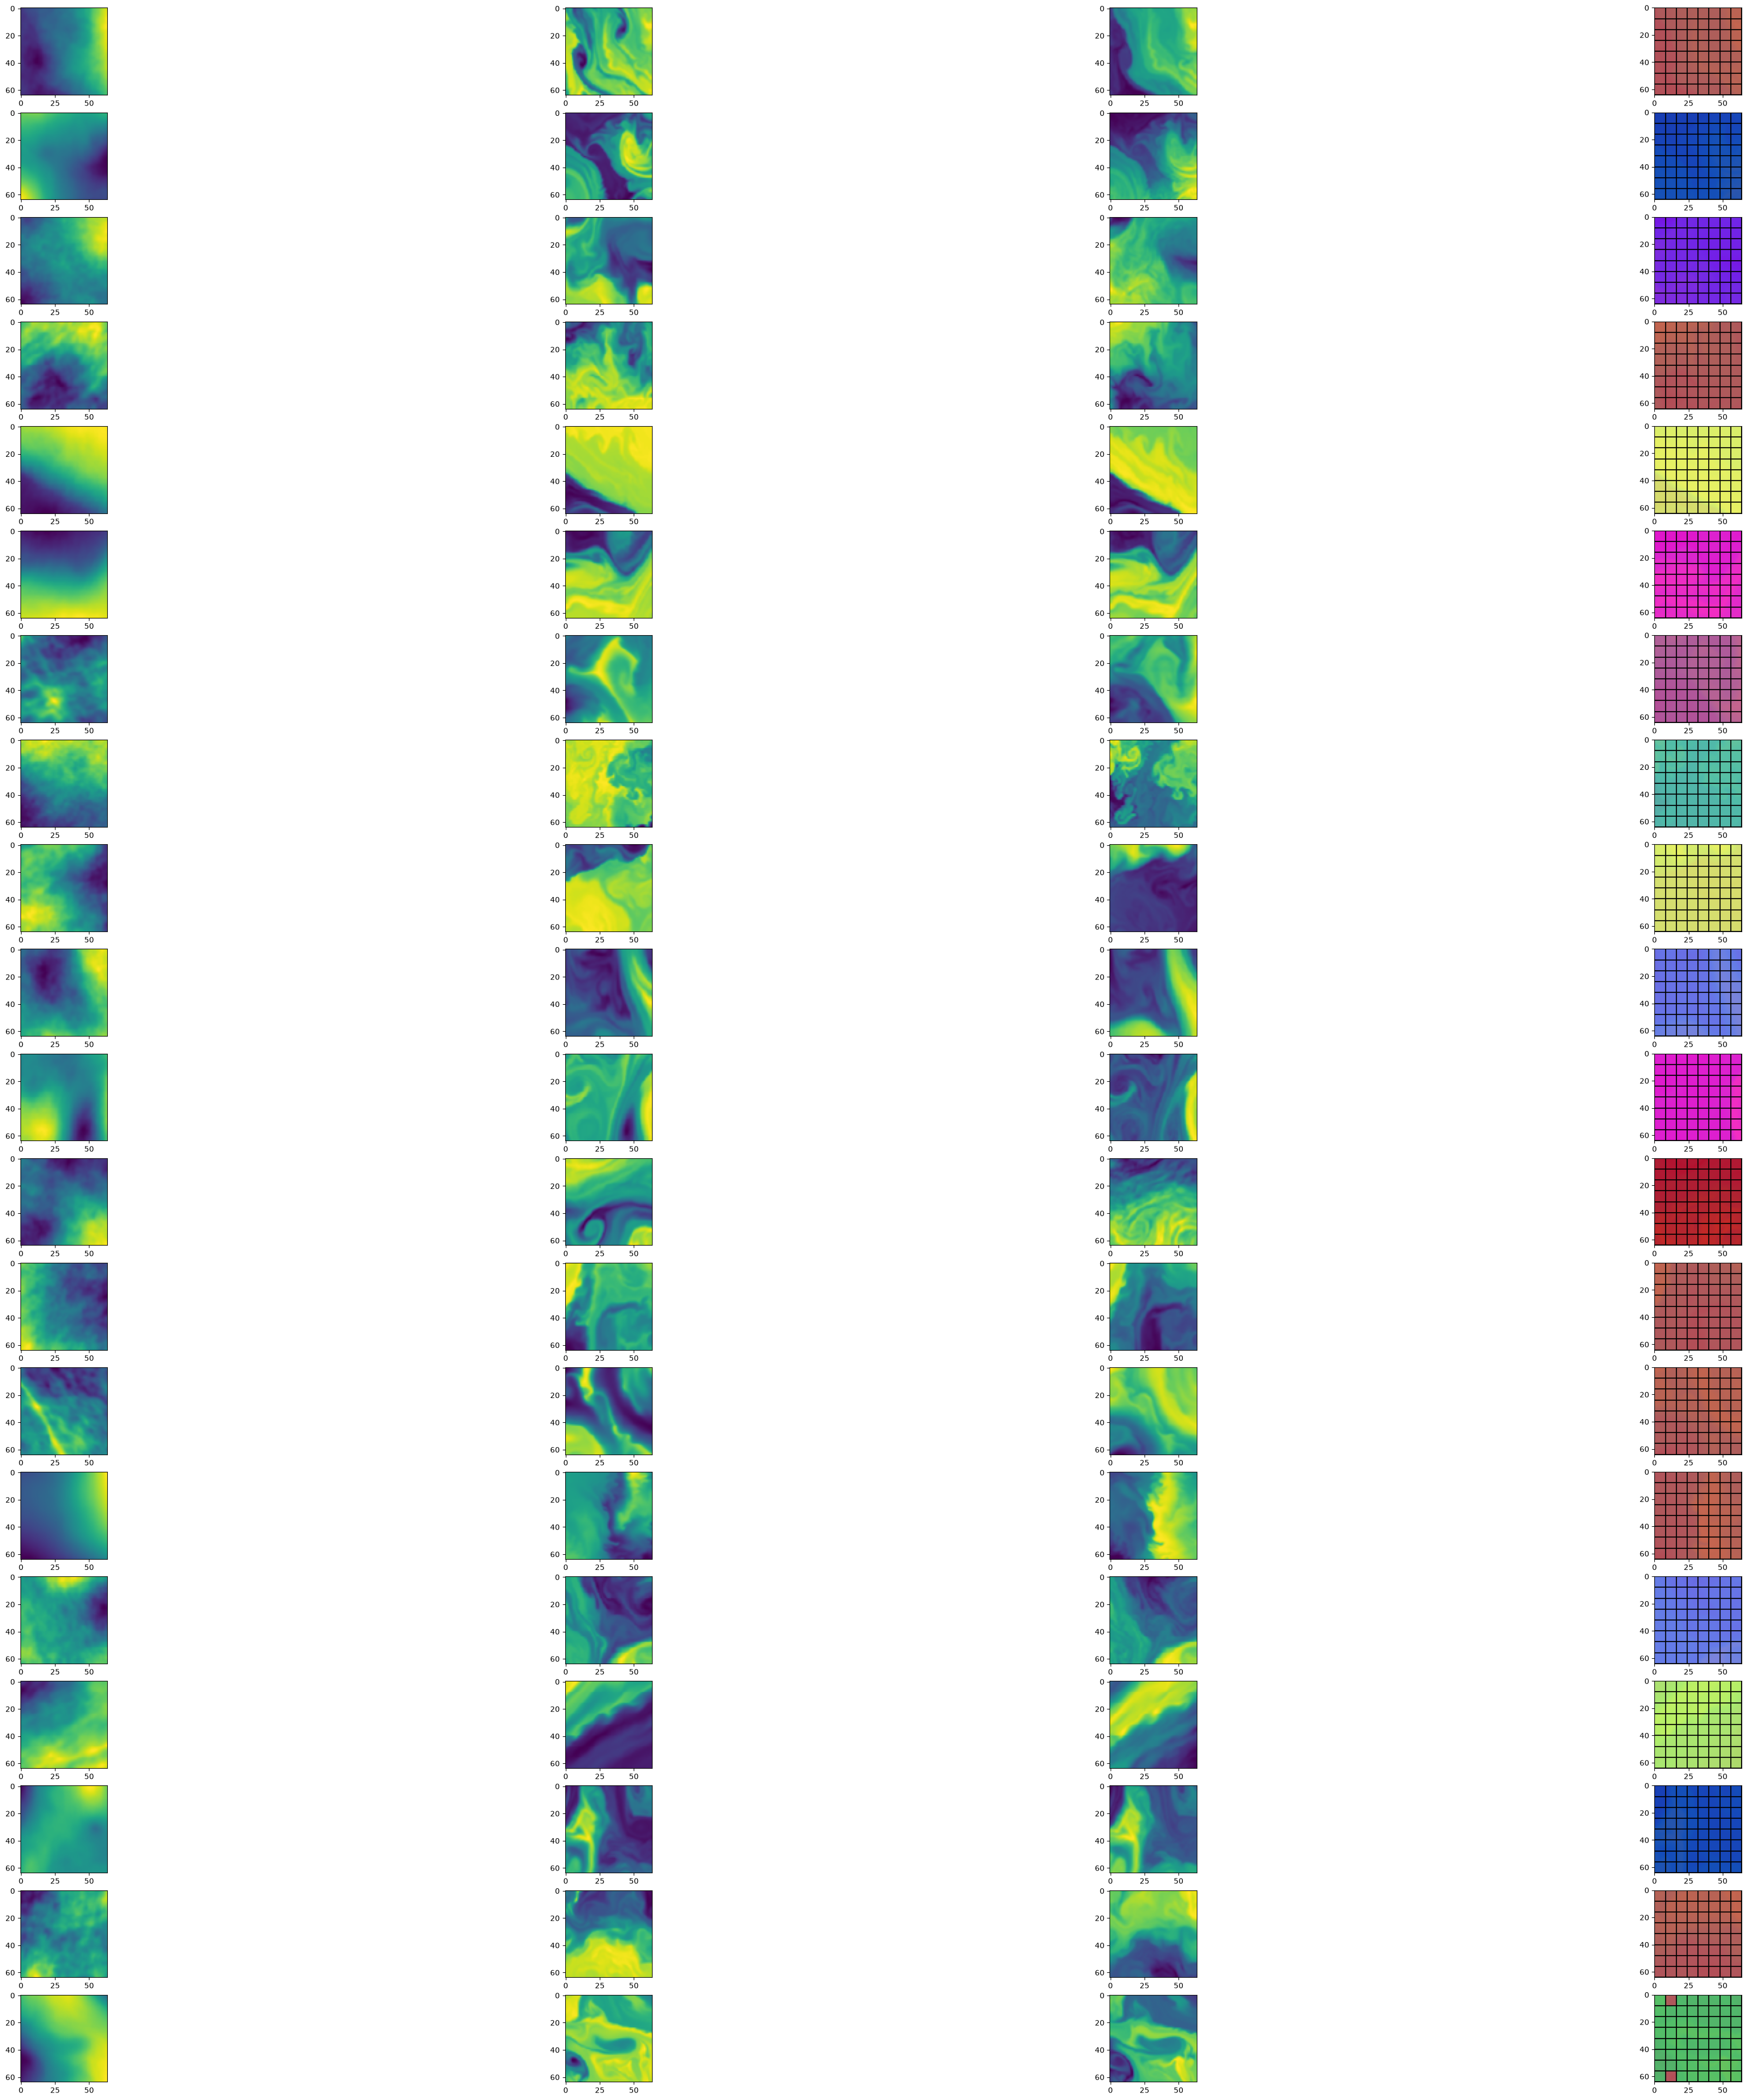

In [20]:
# Patches to Image
def make_image_from_patches(cutouts_dataloader, patched_loader, labels, batch_index=0,
                            batch_size=64, patch_size=8, bg_channel=2, number_rows=6):
    # Requires the loaders to be non-shuffled and deterministic so that `labels`
    # (flat, in loader order) line up with the re-iterated patches.
    batch_imgs = next(itertools.islice(iter(cutouts_dataloader), batch_index, None))
    batch_patches = next(itertools.islice(iter(patched_loader), batch_index, None))

    print(batch_patches.shape)
    print(batch_imgs.shape)

    imgs_in_batch, patches_per_image = batch_patches.shape[0], batch_patches.shape[1]
    number_rows = min(number_rows, imgs_in_batch)

    # One discrete colour per cluster id, shared across all panels.
    n_clusters = int(labels.max()) + 1
    disc_cmap = distinct_cmap(n_clusters)
    norm = BoundaryNorm(np.arange(n_clusters + 1) - 0.5, n_clusters)

    fig, axes = plt.subplots(number_rows, 4, figsize=(50, 50))
    for i in range(number_rows):
        img = batch_imgs[i]
        for c in range(3):
            axes[i, c].imshow(img[c])

        H, W = img.shape[1], img.shape[2]
        n_patches_h, n_patches_w = H // patch_size, W // patch_size

        # reconstruct one channel from its patches as the overlay background
        patches = batch_patches[i]
        bg = rearrange(patches[:, bg_channel], '(h w) p1 p2 -> (h p1) (w p2)',
                       h=n_patches_h, w=n_patches_w)
        axes[i, 3].imshow(bg, extent=[0, W, H, 0])

        # labels are flat in loader order: preceding (full) batches, then earlier
        # images in this batch.
        start = batch_index * batch_size * patches_per_image + i * patches_per_image
        patch_labels = np.asarray(labels[start:start + patches_per_image])
        assert patch_labels.size == n_patches_h * n_patches_w, \
            f"expected {n_patches_h * n_patches_w} labels, got {patch_labels.size}"
        label_grid = patch_labels.reshape(n_patches_h, n_patches_w)

        axes[i, 3].imshow(label_grid, cmap=disc_cmap, norm=norm, alpha=0.9,
                          extent=[0, W, H, 0], interpolation='nearest')

        for g in range(0, H + 1, patch_size):
            axes[i, 3].axhline(g, color='black', linewidth=1.5, alpha=0.9)
        for g in range(0, W + 1, patch_size):
            axes[i, 3].axvline(g, color='black', linewidth=1.5, alpha=0.9)


make_image_from_patches(cutouts_dataloader, patched_loader,clusters, batch_index=0, batch_size=64, number_rows=20)